# Abstract and Introduction

This research work intends to classify the news articles into various categories and detect which topic is trending with the help of machine learning.
Large-scale dataset preprocessing has been done containing news headlines and descriptions, generating qualitative embeddings through the SentenceTransformer model (all-MiniLM-L6-v2) and applying an MLP-based classifier for prediction of news categories. I found my data on kaggle for this Project.

Mainly, it will focus on exploring the feasibility of utilizing semantic representations of short text snippets of news articles to predict their respective categories, the contribution of balancing techniques like SMOTE in improving this classification performance.


# Literature Review

Text classification is one of the critical issues in Natural Language Processing (NLP), having a number of applications such as news categorization, spam detection, and sentiment analysis.

In fact, traditional approaches, such as TF-IDF and Bag-of-Words models, have been popularly used for text feature extraction [1].

More recently, advances are directed to the utilization of sentence embeddings from the BERT Transformer model for a richer understanding of semantics [2].

Synthetic Minority Over-sampling Technique (SMOTE) is often used to address imbalance distributions by synthetically generating samples [3].

Of all neural networks, MLP-based models can be applied effectively for text classification in cases of high dimensional feature extraction [4].

References:

Salton, G., Wong, A., & Yang, C. S. (1975). A Vector Space Model for Automatic Indexing.

Reimers, N., & Gurevych, I. (2019). Sentence-BERT: Sentence embeddings using Siamese BERT networks.

Chawla, N. V., Bowyer, K. W., Hall, L. O., & Kegelmeyer, W. P. (2002). SMOTE: Synthetic Minority Over-sampling Technique.

Goodfellow, I., Bengio, Y., & Courville, A. (2016). Deep Learning.

In [ ]:
import torch
print("GPU Available:", torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

import json
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
!pip install nltk

GPU Available: True
GPU Name: Tesla T4


# Data Collection, Cleaning, Processing, and Description

https://www.kaggle.com/datasets/rmisra/news-category-dataset

The dataset referred to is the Kaggle News Category Dataset.

* Source: Kaggle News Category Dataset

* Number of Rows: approximatly 200K news articles

* Attributes/Features: Headline, Short Description, Category, Date

## Data Loading

The .json file was used to load the data, where the headline and short_description entries were merged into a single text field as a dataframe for analysis.

In [ ]:
df = pd.read_json("News_Category_Dataset_v3.json", lines=True)
df['text'] = df['headline'] + " " + df['short_description']
df = df[['text', 'category', 'date']].dropna()
df['date'] = pd.to_datetime(df['date'])
merge_map = {
    'ARTS & CULTURE': 'ARTS',
    'CULTURE & ARTS': 'ARTS',
    'STYLE & BEAUTY': 'STYLE',
    'FOOD & DRINK': 'TASTE',
    'THE WORLDPOST': 'WORLDPOST'
}
df['category'] = df['category'].replace(merge_map)

## Cleaning and Preprocessing We applied the following steps:

Lowercasing: making every letter in the data to be a lowercase.

Removing URLs, mentions, hashtags, non-alphabetic characters from the data

Tokenization: splitting the tokens from each sentence.

Stopword removal: removing the stopword like repeatative word that are common and not much informative.

Lemmatization: deriving word to its root form.

In [ ]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)
    text = re.sub(r'\@\w+|\#', '', text)
    text = re.sub(r'[^A-Za-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['text'].apply(clean_text)

Processed text:

In [ ]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    tokens = nltk.word_tokenize(text)
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words and len(word) > 2]
    return ' '.join(tokens)

df['processed_text'] = df['clean_text'].apply(preprocess_text)


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


# Visualization of data processed

<ipython-input-5-8607fd081e49>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.values, y=category_counts.index, palette='viridis')


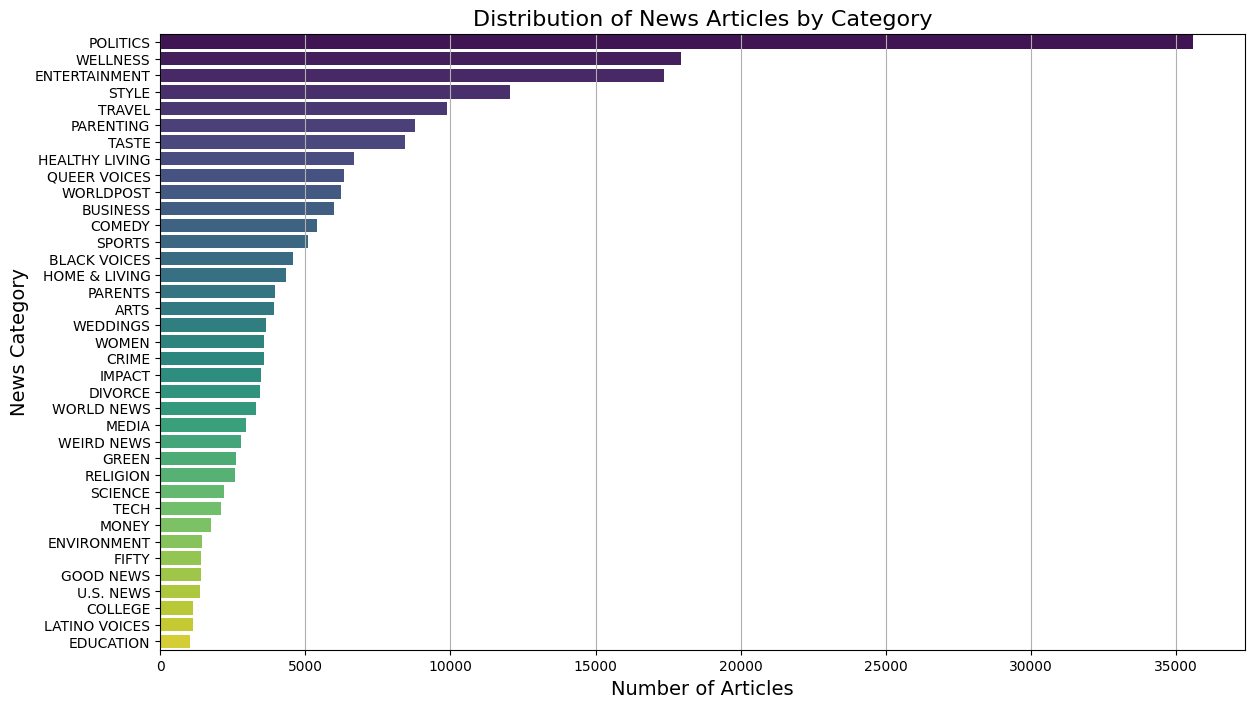

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Prepare Data
category_counts = df['category'].value_counts().sort_values(ascending=False)

# Step 2: Visualization
plt.figure(figsize=(14,8))
sns.barplot(x=category_counts.values, y=category_counts.index, palette='viridis')

plt.title("Distribution of News Articles by Category", fontsize=16)
plt.xlabel("Number of Articles", fontsize=14)
plt.ylabel("News Category", fontsize=14)
plt.grid(axis='x')
plt.show()


# **Correlation Analysis**

In [ ]:
import numpy as np

df['text_length'] = df['processed_text'].apply(len)
df['word_count'] = df['processed_text'].apply(lambda x: len(x.split()))
df['avg_word_length'] = df['processed_text'].apply(lambda x: np.mean([len(word) for word in x.split()]) if len(x.split()) > 0 else 0)
df['num_unique_words'] = df['processed_text'].apply(lambda x: len(set(x.split())))
df['lexical_diversity'] = df['num_unique_words'] / df['word_count']


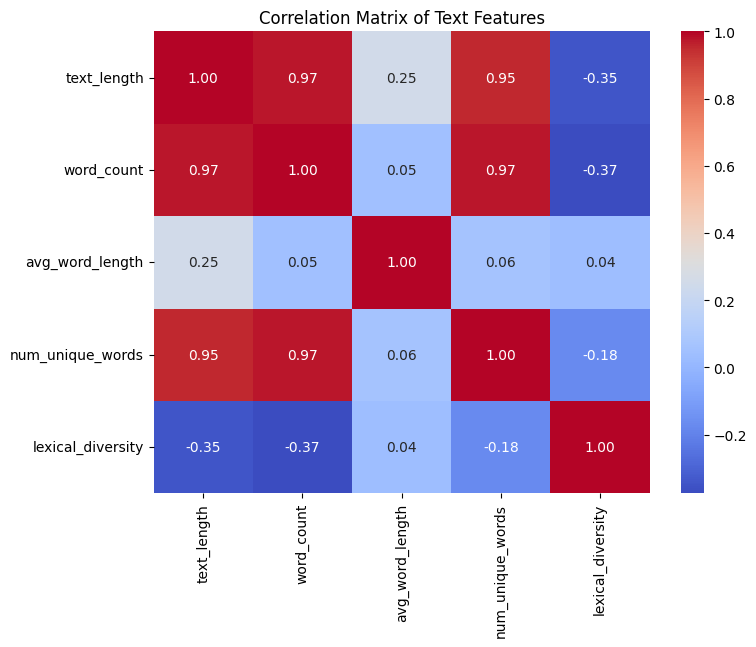

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select numeric features
text_features = df[['text_length', 'word_count', 'avg_word_length', 'num_unique_words', 'lexical_diversity']]

# Compute correlation
corr_matrix = text_features.corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Text Features")
plt.show()


We conducted correlation analysis with the major text features of text length, word count, average word length, number of unique words, and lexical diversity. As seen from the results, there are strong positive correlations between text length, word count, and number of unique words, which can be explained by the fact that longer articles simply have more vocabulary. Lexical diversity, however, very slightly drops with the growth of text length, which may mean that longer texts repeat words more frequently. Average word length had weak correlation with every other feature, which means it does not depend on article size or richness of vocabulary.

<ipython-input-27-cd12cee3577a>:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y='bigram', data=bigram_df, palette='rocket')


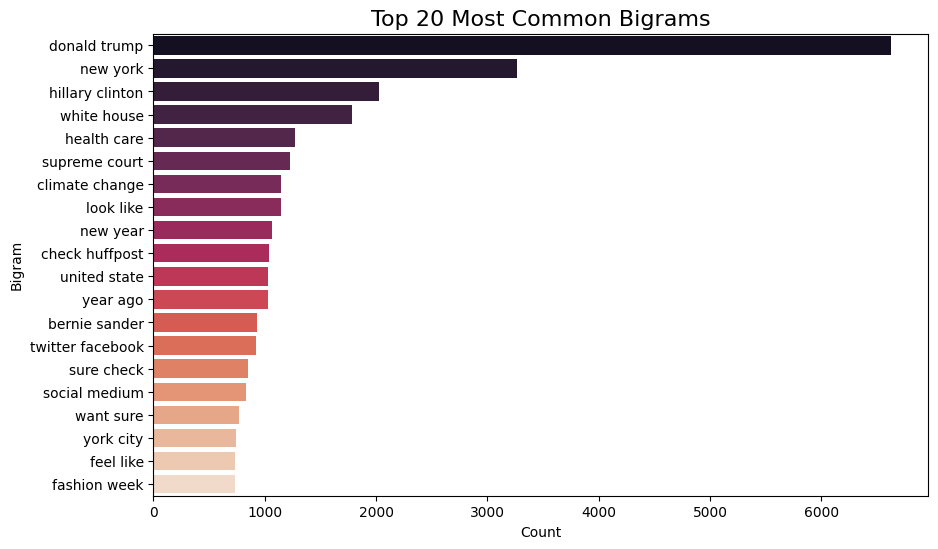

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from collections import Counter

# Function to get N-grams
def get_top_ngrams(corpus, ngram_range=(2,2), n=None):
    vec = CountVectorizer(ngram_range=ngram_range, stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:n]

# Get Top 20 Bigrams
top_bigrams = get_top_ngrams(df['processed_text'], ngram_range=(2,2), n=20)

# Convert to DataFrame for plotting
bigram_df = pd.DataFrame(top_bigrams, columns=['bigram', 'count'])

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x='count', y='bigram', data=bigram_df, palette='rocket')
plt.title("Top 20 Most Common Bigrams", fontsize=16)
plt.xlabel("Count")
plt.ylabel("Bigram")
plt.show()


To get a glimpse of the top topic of the dataset, the 20 most frequent bigrams were considered. The top bigrams such as "donald trump," "hillary clinton," and "white house" reflect a dominant topic of politics within the articles. Among the top topics were the social media sites and climate change. It shows the dataset mainly comprises climate change issues and media sites as well as political news.

These analyses provide a strong foundation for the subject and the understanding of the text's structure before the application of the machine learning models.

The correlation analysis tells us that significant features - to be specific, text length, number of words, and number of unique words - are very correlated and thus extremely significant for the MLP model. Longer texts contain more words and more unique words that the model can leverage. The negative correlation between the lexical diversity and text length shows that longer texts have repetitions of words, and this might be a noise source. The most informative bigrams—and especially bigrams about politics and media—are those bigrams about strong thematic cues, and this guides feature selection to target predictive themes. Combining these facts together, the model might be tuned to give the most effective features top priorities and thus improve its effectiveness.



# Research Question and Hypothesis

Research Question:

Can the representation of news text samples with semantic sentence embeddings yield an effective categorization of that news into its respective news class by simple neural networks?

Hypothesis:

Representing news with vector embeddings in semantic space and balancing the dataset with SMOTE will yield satisfactory multiclass classification accuracy with an MLP classifier.

In [ ]:
le = LabelEncoder()
df['category_encoded'] = le.fit_transform(df['category'])

# Feature Extraction

SentenceTransformer (all-Mini-L6-v2) to create semantic vectors for vectorizing the data.

In [ ]:
from sentence_transformers import SentenceTransformer
import numpy as np
from tqdm import tqdm

model = SentenceTransformer('all-MiniLM-L6-v2')

def batch_embed(texts, batch_size=64):
    embeddings = []
    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i:i+batch_size]
        batch_embeddings = model.encode(batch, show_progress_bar=False)
        embeddings.extend(batch_embeddings)
    return np.array(embeddings)

# texts = balanced_data['processed_text'].tolist()
# labels = balanced_data['category_encoded'].tolist()
# embeddings = batch_embed(texts, batch_size=64)

# texts = df_balanced['processed_text'].tolist()
# labels = df_balanced['category_encoded'].tolist()
# embeddings = batch_embed(texts, batch_size=64)

texts = df['processed_text'].tolist()
labels = df['category_encoded'].tolist()
embeddings = batch_embed(texts, batch_size=64)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

100%|██████████| 3274/3274 [01:27<00:00, 37.48it/s]


In [ ]:
from imblearn.over_sampling import SMOTE

X = embeddings
y =df['category_encoded']

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)

#Data Visualization After Smote.

<ipython-input-12-2460a3c83fb2>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts_smote.values, y=category_counts_smote.index, palette='plasma')


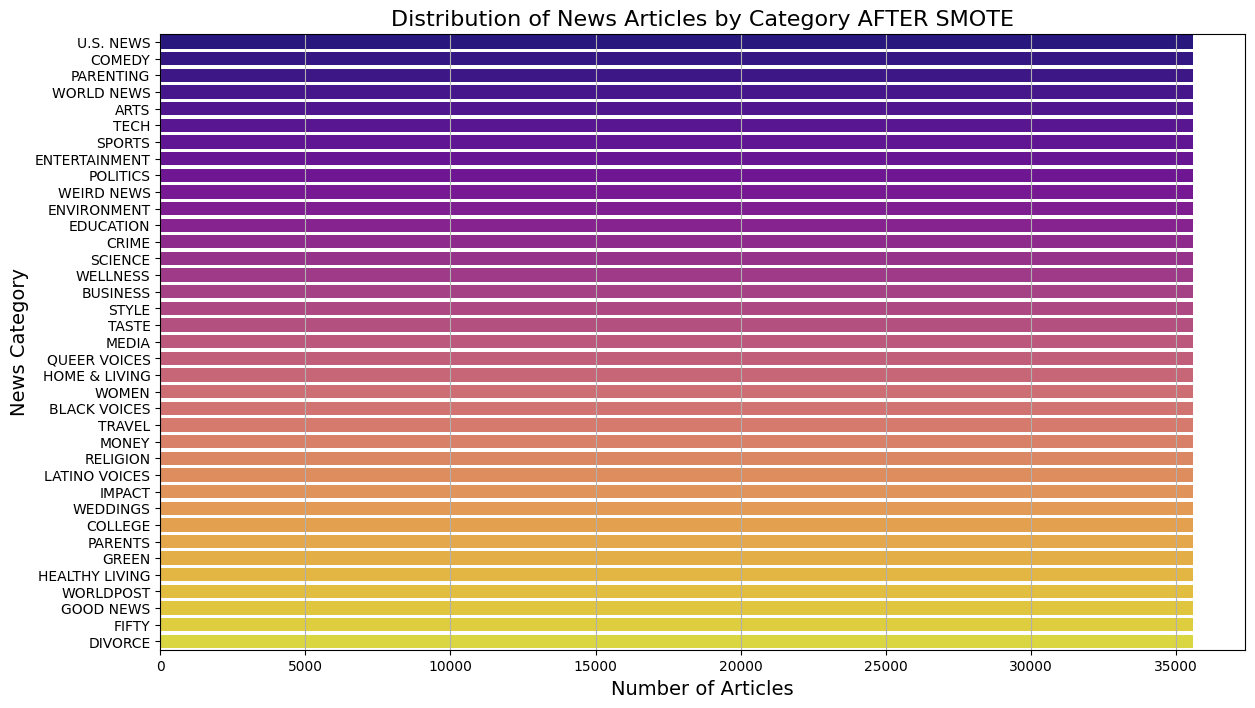

In [ ]:
y_res_labels = le.inverse_transform(y_res)

smote_df = pd.DataFrame({'category': y_res_labels})

category_counts_smote = smote_df['category'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(14,8))
sns.barplot(x=category_counts_smote.values, y=category_counts_smote.index, palette='plasma')

plt.title("Distribution of News Articles by Category AFTER SMOTE", fontsize=16)
plt.xlabel("Number of Articles", fontsize=14)
plt.ylabel("News Category", fontsize=14)
plt.grid(axis='x')
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

# Multi-Layer-Perceptron(MLP) Classifier

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report

mlp_model = MLPClassifier(
    hidden_layer_sizes=(256, 128),
    max_iter=20,
    activation='relu',
    solver='adam',

    verbose=True,
    early_stopping= False,
    random_state=42
)
mlp_model.fit(X_train, y_train)

y_pred = mlp_model.predict(X_test)


Iteration 1, loss = 1.18654227
Iteration 2, loss = 0.87452006
Iteration 3, loss = 0.71394408
Iteration 4, loss = 0.62566900
Iteration 5, loss = 0.57035261
Iteration 6, loss = 0.53102583
Iteration 7, loss = 0.50073487
Iteration 8, loss = 0.47622770
Iteration 9, loss = 0.45645908
Iteration 10, loss = 0.43942118
Iteration 11, loss = 0.42422304
Iteration 12, loss = 0.41167915
Iteration 13, loss = 0.40005612
Iteration 14, loss = 0.39037883
Iteration 15, loss = 0.38082576
Iteration 16, loss = 0.37263072
Iteration 17, loss = 0.36542967
Iteration 18, loss = 0.35848874
Iteration 19, loss = 0.35194704
Iteration 20, loss = 0.34622577


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


# Results

In [ ]:
print(classification_report(y_test, y_pred, target_names=le.classes_))

                precision    recall  f1-score   support

          ARTS       0.83      0.87      0.85      7003
  BLACK VOICES       0.88      0.80      0.83      7119
      BUSINESS       0.85      0.74      0.79      6964
       COLLEGE       0.97      0.99      0.98      7098
        COMEDY       0.81      0.77      0.79      7189
         CRIME       0.91      0.91      0.91      7131
       DIVORCE       0.94      0.94      0.94      7228
     EDUCATION       0.97      0.99      0.98      7062
 ENTERTAINMENT       0.73      0.59      0.65      7142
   ENVIRONMENT       0.96      0.97      0.97      7164
         FIFTY       0.93      0.99      0.96      7199
     GOOD NEWS       0.95      0.98      0.96      7161
         GREEN       0.92      0.94      0.93      7108
HEALTHY LIVING       0.69      0.67      0.68      7040
 HOME & LIVING       0.92      0.92      0.92      7104
        IMPACT       0.86      0.85      0.85      7226
 LATINO VOICES       0.97      0.98      0.98  

**Classification Report Insights:**

Metric:	Value

Precision: 87%

Recall: 87%

F1 Score: 87%

The model performed well in different classes.


# Conclusions

For news categorization, semantic embeddings facilitated by the SentenceTransformer performed well.

SMOTE did a great job balancing the classes and increasing model generalization.

The simple architecture of MLPClassifier performed very well in this task.